# Bengaluru House Price Prediction

**Refined Capstone Project | Linear Regression**

## Project objective

Build a linear regression model that predicts residential property prices in Bengaluru, India, using the Bengaluru Home Prices dataset.

The project follows an end-to-end workflow:

1. Understand the raw data
2. Clean and validate the variables
3. Explore relationships with house price
4. Engineer modelling features
5. Split the data into training and test sets
6. Build preprocessing and linear regression pipelines
7. Validate the model using 5-fold cross-validation
8. Evaluate final performance on an untouched test set
9. Inspect residuals and model coefficients
10. Demonstrate how the trained model can be used for prediction

### Modelling constraint

The capstone specification requires **linear regression**. Therefore, linear regression is the primary predictive model rather than choosing a more complex algorithm solely to maximise predictive performance.

## 1. Problem statement and business context

A real-estate analytics company wants a price-estimation tool for homes in Bengaluru. The model should learn the relationship between property characteristics and observed sale prices and provide a reproducible baseline for price estimation.

### Target

- `price`: property price, measured in **Indian lakhs**

### Candidate information available in the dataset

- `location`
- `total_sqft`
- `size`
- `bath`
- `balcony`
- `area_type`
- `availability`
- `society`

The modelling objective is to predict `price`.

### Important modelling principle

A variable derived from `price` must not be used as a predictor. For example, `price_per_sqft` is useful for exploratory analysis, but it contains the target and would cause target leakage if supplied to the model.

In [1]:
# Core libraries
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the raw dataset

The original CSV is expected at `data/Bengaluru_House_Data.csv`. Keeping the raw dataset outside the notebook code makes the workflow easier to reproduce.

In [2]:
candidate_paths = [
    Path("data/Bengaluru_House_Data.csv"),
    Path("Bengaluru_House_Data.csv"),
    Path("/content/Bengaluru_House_Data.csv"),  # Google Colab
]

data_path = next((p for p in candidate_paths if p.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Dataset not found. Place Bengaluru_House_Data.csv inside the data/ folder "
        "or update candidate_paths."
    )

df_raw = pd.read_csv(data_path)

print(f"Loaded: {data_path}")
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
display(df_raw.head())

Loaded: data/Bengaluru_House_Data.csv
Shape: 13,320 rows × 9 columns


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.000,1.000,39.070
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.000,3.000,120.000
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.000,3.000,62.000
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.000,1.000,95.000
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.000,1.000,51.000


In [3]:
print("Column names:")
print(df_raw.columns.tolist())

print("\nData types:")
display(df_raw.dtypes.to_frame("dtype"))

print("\nMissing values:")
missing = (
    df_raw.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda x: 100 * x["missing_count"] / len(df_raw))
    .query("missing_count > 0")
    .sort_values("missing_pct", ascending=False)
)
display(missing)

print(f"Exact duplicate rows: {df_raw.duplicated().sum():,}")

print("\nNumeric summary:")
display(df_raw.describe(include="all").T)

Column names:
['area_type', 'availability', 'location', 'size', 'society', 'total_sqft', 'bath', 'balcony', 'price']

Data types:


,dtype
area_type,object
availability,object
location,object
size,object
society,object
total_sqft,object
bath,float64
balcony,float64
price,float64



Missing values:


,missing_count,missing_pct
society,5502,41.306
balcony,609,4.572
bath,73,0.548
size,16,0.120
location,1,0.008


Exact duplicate rows: 529

Numeric summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
area_type,13320,4,Super built-up Area,8790,NaN,NaN,NaN,NaN,NaN,NaN,NaN
availability,13320,81,Ready To Move,10581,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,13319,1305,Whitefield,540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size,13304,31,2 BHK,5199,NaN,NaN,NaN,NaN,NaN,NaN,NaN
society,7818,2688,GrrvaGr,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_sqft,13320,2117,1200,843,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bath,"13,247.000",NaN,NaN,NaN,2.693,1.341,1.000,2.000,2.000,3.000,40.000
balcony,"12,711.000",NaN,NaN,NaN,1.584,0.817,0.000,1.000,2.000,2.000,3.000
price,"13,320.000",NaN,NaN,NaN,112.566,148.972,8.000,50.000,72.000,120.000,"3,600.000"


## 3. Data cleaning and feature engineering

The raw dataset contains several issues typical of real-world tabular data:

- `society` has substantial missingness and is not required for the capstone model.
- `total_sqft` is stored as text and contains ranges and unit expressions.
- `size` contains values such as `2 BHK` and `4 Bedroom`.
- `location` has high cardinality.
- `bath` and `balcony` contain missing values.
- Some observations are implausible for the intended residential modelling population.

The cleaning rules below are defined **before model evaluation** and are not tuned to the test-set score.

In [4]:
df = df_raw.copy()

# Standardise column names.
df.columns = [c.strip().lower() for c in df.columns]

# Remove exact duplicate records.
before = len(df)
df = df.drop_duplicates().copy()
duplicate_rows_removed = before - len(df)

# Society has substantial missingness and is not needed for the specified model.
# Dropping it also avoids building a sparse feature from a field with limited coverage.
if "society" in df.columns:
    df = df.drop(columns="society")

print(f"Exact duplicate rows removed: {duplicate_rows_removed:,}")

Exact duplicate rows removed: 529


In [5]:
# Convert total_sqft to a numeric square-foot value.
SQFT_PER_UNIT = {
    "sq. meter": 10.7639,
    "sq meter": 10.7639,
    "sq. m": 10.7639,
    "sq. yards": 9.0,
    "sq yard": 9.0,
    "perch": 272.25,
    "ground": 2400.0,
    "acre": 43560.0,
    "acres": 43560.0,
    "guntha": 1089.0,
    "cent": 435.6,
}

def parse_total_sqft(value):
    if pd.isna(value):
        return np.nan

    s = str(value).strip().lower()

    if not s:
        return np.nan

    # Convert ranges such as "1000-1200" to their midpoint.
    range_match = re.search(
        r"([0-9]+(?:\.[0-9]+)?)\s*-\s*([0-9]+(?:\.[0-9]+)?)",
        s
    )
    if range_match:
        low = float(range_match.group(1))
        high = float(range_match.group(2))
        return (low + high) / 2

    # Convert recognised units to square feet.
    for unit, multiplier in sorted(
        SQFT_PER_UNIT.items(),
        key=lambda x: -len(x[0])
    ):
        if unit in s:
            number_match = re.search(r"[0-9]+(?:\.[0-9]+)?", s)
            if number_match:
                return float(number_match.group()) * multiplier
            return np.nan

    # Plain numeric value.
    number_match = re.fullmatch(r"\s*[0-9]+(?:\.[0-9]+)?\s*", s)
    if number_match:
        return float(number_match.group())

    return np.nan

df["total_sqft"] = df["total_sqft"].apply(parse_total_sqft)

# Extract number of bedrooms from values such as "2 BHK" or "4 Bedroom".
df["bhk"] = (
    df["size"]
    .astype("string")
    .str.extract(r"(\d+(?:\.\d+)?)", expand=False)
    .astype(float)
)

df["price"] = pd.to_numeric(df["price"], errors="coerce")

df["location"] = (
    df["location"]
    .astype("string")
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# Availability is simplified to a reproducible binary feature.
df["ready_to_move"] = (
    df["availability"]
    .astype("string")
    .str.strip()
    .str.lower()
    .eq("ready to move")
    .astype(int)
)

display(df[["total_sqft", "bhk", "price", "location", "ready_to_move"]].head())

,total_sqft,bhk,price,location,ready_to_move
0,"1,056.000",2.000,39.070,Electronic City Phase II,0
1,"2,600.000",4.000,120.000,Chikka Tirupathi,1
2,"1,440.000",3.000,62.000,Uttarahalli,1
3,"1,521.000",3.000,95.000,Lingadheeranahalli,1
4,"1,200.000",2.000,51.000,Kothanur,1


In [6]:
# Remove observations that cannot be used for the target prediction task.
required_columns = ["price", "location", "bhk", "total_sqft"]

before = len(df)
df = df.dropna(subset=required_columns).copy()
missing_required_removed = before - len(df)

# Domain/data-quality plausibility rules.
before = len(df)

df = df[
    (df["price"] > 0) &
    (df["total_sqft"] > 0) &
    (df["bhk"].between(1, 10))
].copy()

df["sqft_per_bhk"] = df["total_sqft"] / df["bhk"]
df = df[df["sqft_per_bhk"] >= 300].copy()

if "bath" in df.columns:
    df = df[(df["bath"].isna()) | (df["bath"].between(1, 10))].copy()

plausibility_removed = before - len(df)

print(f"Rows removed for missing required fields: {missing_required_removed:,}")
print(f"Rows removed by plausibility rules:       {plausibility_removed:,}")
print(f"Final cleaned dataset:                     {len(df):,} rows")

Rows removed for missing required fields: 17
Rows removed by plausibility rules:       746
Final cleaned dataset:                     12,028 rows


### Why these cleaning rules?

- **`total_sqft` ranges:** the midpoint is a transparent approximation when only a range is supplied.
- **BHK extraction:** the numeric part of `size` is retained as a structured feature.
- **`sqft_per_bhk >= 300`:** extremely small area-per-bedroom observations are treated as likely data-quality anomalies for this residential dataset.
- **`bath` between 1 and 10:** unusually large bathroom counts are treated as implausible for the intended modelling population.
- **No arbitrary price cap:** price outliers are not removed merely because they make the model harder. The model should be evaluated on the cleaned population rather than on a threshold selected to improve the score.

## 4. Exploratory data analysis

EDA is used to understand the data and motivate modelling decisions. Features derived from the target are kept strictly out of the predictive pipeline.

In [7]:
# Descriptive feature for EDA only.
df["price_per_sqft"] = (df["price"] * 100000) / df["total_sqft"]

display(
    df[["price", "total_sqft", "bhk", "bath", "balcony", "price_per_sqft"]]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
price,"12,028.000",112.940,151.307,9.000,50.000,70.000,120.000,"2,912.000"
total_sqft,"12,028.000","1,991.931","18,177.959",300.000,"1,116.000","1,305.500","1,717.000","1,306,800.000"
bhk,"12,028.000",2.657,0.967,1.000,2.000,3.000,3.000,10.000
bath,"11,971.000",2.570,1.064,1.000,2.000,2.000,3.000,10.000
balcony,"11,534.000",1.585,0.815,0.000,1.000,2.000,2.000,3.000
price_per_sqft,"12,028.000","6,353.316","4,207.640",2.257,"4,245.187","5,327.486","6,969.337","176,470.588"


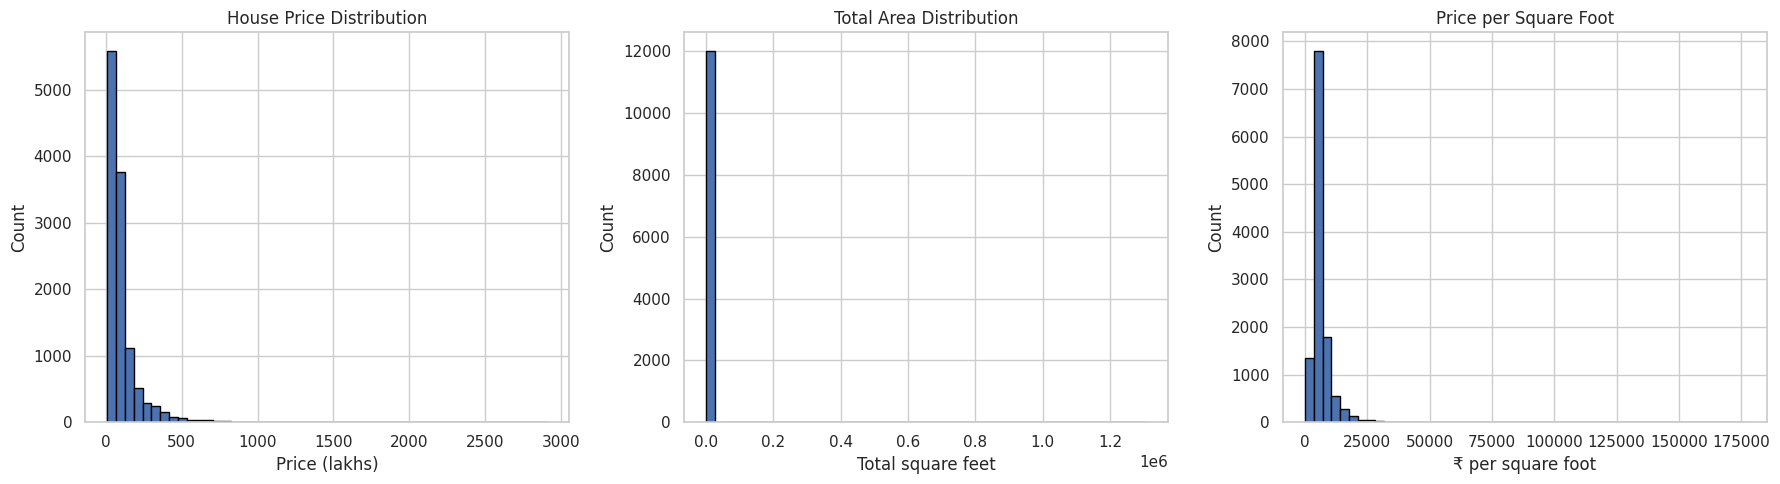

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df["price"], bins=50, edgecolor="black")
axes[0].set_title("House Price Distribution")
axes[0].set_xlabel("Price (lakhs)")
axes[0].set_ylabel("Count")

axes[1].hist(df["total_sqft"], bins=50, edgecolor="black")
axes[1].set_title("Total Area Distribution")
axes[1].set_xlabel("Total square feet")
axes[1].set_ylabel("Count")

axes[2].hist(df["price_per_sqft"], bins=50, edgecolor="black")
axes[2].set_title("Price per Square Foot")
axes[2].set_xlabel("₹ per square foot")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

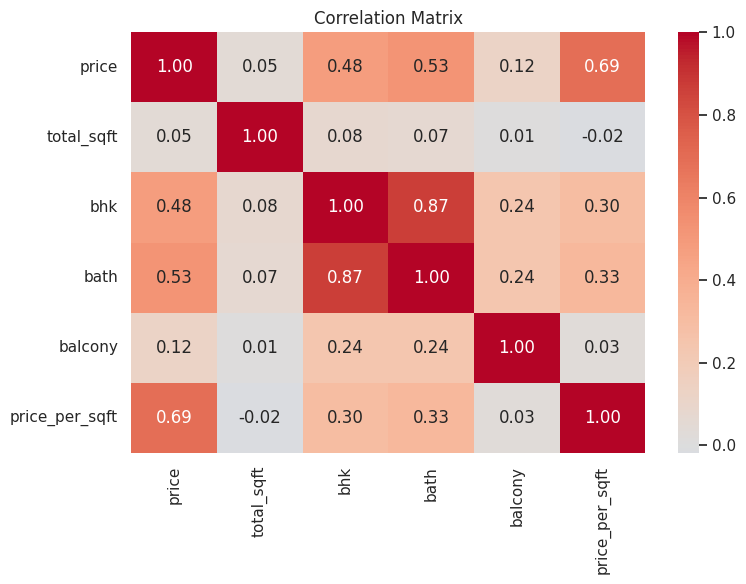

,correlation_with_price
price,1.000
price_per_sqft,0.691
bath,0.528
bhk,0.480
balcony,0.118
total_sqft,0.049


In [9]:
numeric_for_eda = [
    "price",
    "total_sqft",
    "bhk",
    "bath",
    "balcony",
    "price_per_sqft",
]

corr = df[numeric_for_eda].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", center=0, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

display(
    corr["price"]
    .sort_values(ascending=False)
    .to_frame("correlation_with_price")
)

Unique locations: 1,207


,property_count
location,
Whitefield,522
Sarjapur Road,373
Electronic City,281
Kanakpura Road,247
Thanisandra,231
Yelahanka,204
Marathahalli,164
Hebbal,160
Raja Rajeshwari Nagar,158


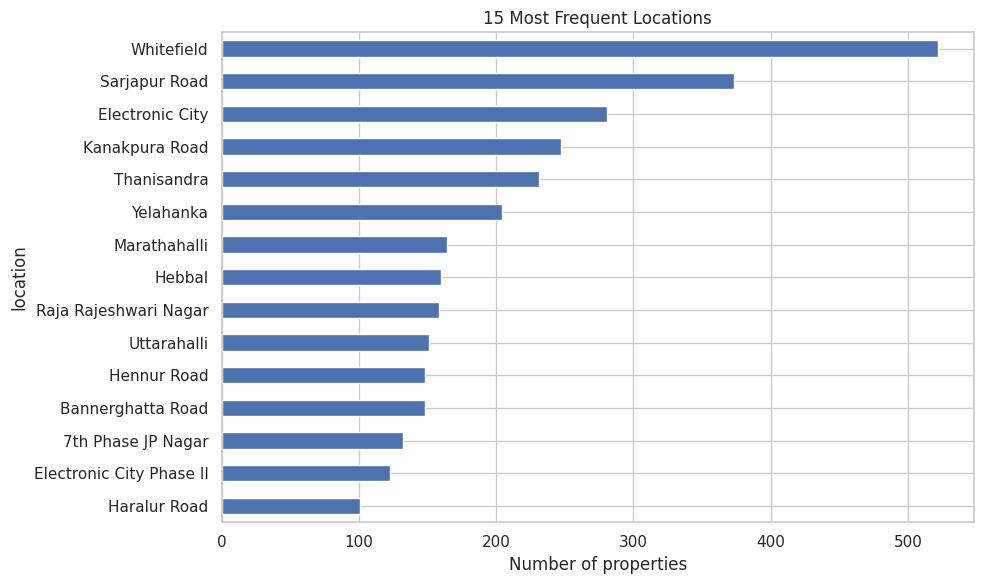

In [10]:
location_counts = df["location"].value_counts()

print(f"Unique locations: {location_counts.size:,}")
display(location_counts.head(20).to_frame("property_count"))

plt.figure(figsize=(10, 6))
location_counts.head(15).sort_values().plot(kind="barh")
plt.title("15 Most Frequent Locations")
plt.xlabel("Number of properties")
plt.tight_layout()
plt.show()

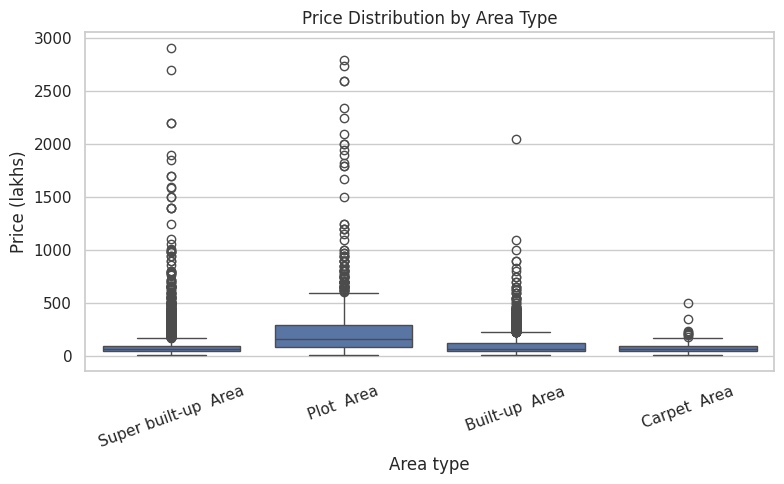

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="area_type", y="price")
plt.title("Price Distribution by Area Type")
plt.xlabel("Area type")
plt.ylabel("Price (lakhs)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 5. Define the modelling dataset

The target is `price`.

Predictors:

- `location`
- `total_sqft`
- `bhk`
- `bath`
- `balcony`
- `area_type`
- `ready_to_move`

### Leakage control

`price_per_sqft` is deliberately excluded because:

\[
price\_per\_sqft = \frac{price \times 100000}{total\_sqft}
\]

It is calculated using the target itself, so including it would allow the model to indirectly see the answer.

In [12]:
target = "price"

feature_columns = [
    "location",
    "total_sqft",
    "bhk",
    "bath",
    "balcony",
    "area_type",
    "ready_to_move",
]

X = df[feature_columns].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

print(f"Training observations: {len(X_train):,}")
print(f"Test observations:     {len(X_test):,}")

Training observations: 9,622
Test observations:     2,406


## 6. Reduce location cardinality without test-set leakage

Location is highly informative but has many unique categories.

Instead of retaining an arbitrary fixed number of locations, the rule used here is:

> Keep locations appearing at least **5 times in the training data**; group the remaining locations as `Other`.

The threshold is applied using **training data only**. This prevents information from the test set from influencing the feature transformation.

In [13]:
MIN_LOCATION_COUNT = 5

location_counts_train = X_train["location"].value_counts()
retained_locations = location_counts_train[
    location_counts_train >= MIN_LOCATION_COUNT
].index

def group_location(series, retained):
    return series.where(series.isin(retained), "Other")

X_train = X_train.copy()
X_test = X_test.copy()

X_train["location"] = group_location(
    X_train["location"],
    retained_locations
)

X_test["location"] = group_location(
    X_test["location"],
    retained_locations
)

print(f"Original training locations: {location_counts_train.size:,}")
print(f"Retained locations:           {len(retained_locations):,}")
print(f"Training locations after grouping: {X_train['location'].nunique():,}")
print(
    f"Training observations retained in named locations: "
    f"{100 * (X_train['location'] != 'Other').mean():.1f}%"
)

Original training locations: 1,097
Retained locations:           357
Training locations after grouping: 358
Training observations retained in named locations: 86.1%


## 7. Build the preprocessing and modelling pipeline

Preprocessing is placed inside a scikit-learn pipeline so that the same transformations are applied consistently during cross-validation, training and prediction.

### Numeric variables

Missing values are imputed with the median and then standardised.

### Categorical variables

Missing values are imputed with the most frequent category and encoded using one-hot encoding.

`handle_unknown="ignore"` ensures that an unseen location at prediction time does not break the pipeline.

In [14]:
numeric_features = [
    "total_sqft",
    "bhk",
    "bath",
    "balcony",
    "ready_to_move",
]

categorical_features = [
    "location",
    "area_type",
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"
    )),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression()),
])

linear_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

## 8. Cross-validation

A single train/test split gives one estimate of model performance. Five-fold cross-validation provides several training/validation estimates using only the training portion.

Metrics:

- **R²:** proportion of target variance explained by the model.
- **RMSE:** typical prediction error with greater penalty for large errors.
- **MAE:** average absolute prediction error.

A mean-price dummy model is included as a simple baseline.

In [15]:
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", DummyRegressor(strategy="mean")),
])

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
}

linear_cv = cross_validate(
    linear_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
)

baseline_cv = cross_validate(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
)

cv_summary = pd.DataFrame({
    "Model": ["Linear Regression", "Mean-price baseline"],
    "Mean R²": [
        linear_cv["test_r2"].mean(),
        baseline_cv["test_r2"].mean(),
    ],
    "SD R²": [
        linear_cv["test_r2"].std(),
        baseline_cv["test_r2"].std(),
    ],
    "Mean RMSE (lakhs)": [
        -linear_cv["test_rmse"].mean(),
        -baseline_cv["test_rmse"].mean(),
    ],
    "Mean MAE (lakhs)": [
        -linear_cv["test_mae"].mean(),
        -baseline_cv["test_mae"].mean(),
    ],
})

display(cv_summary)

Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 124, in start_daemon
TimeoutError: Timed out waiting for artifact tool daemon socket. Set ARTIFACT_TOOL_RPC_DAEMON_STARTUP_TIMEOUT_S=<seconds> to increase the limit.


Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 124, in start_daemon
TimeoutError: Timed out waiting for artifact tool daemon socket. Set ARTIFACT_TOOL_RPC_DAEMON_STARTUP_TIMEOUT_S=<seconds> to increase the limit.


Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 124, in start_daemon
TimeoutError: Timed out waiting for artifact tool daemon socket. Set ARTIFACT_TOOL_RPC_DAEMON_STARTUP_TIMEOUT_S=<seconds> to increase the limit.


Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 124, in start_daemon
TimeoutError: Timed out waiting for artifact tool daemon socket. Set ARTIFACT_TOOL_RPC_DAEMON_STARTUP_TIMEOUT_S=<seconds> to increase the limit.


Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 124, in start_daemon
TimeoutError: Timed out waiting for artifact tool daemon socket. Set ARTIFACT_TOOL_RPC_DAEMON_STARTUP_TIMEOUT_S=<seconds> to increase the limit.
Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_

,Model,Mean R²,SD R²,Mean RMSE (lakhs),Mean MAE (lakhs)
0,Linear Regression,0.419,0.031,112.341,50.170
1,Mean-price baseline,-0.001,0.001,147.729,75.824


## 9. Fit the final linear regression model and evaluate on the test set

The test set has remained untouched during model selection and cross-validation. It is used once here for the final performance estimate.

In [16]:
linear_model.fit(X_train, y_train)

y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

def regression_metrics(y_true, y_pred):
    return {
        "R²": r2_score(y_true, y_pred),
        "RMSE (lakhs)": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE (lakhs)": mean_absolute_error(y_true, y_pred),
    }

train_metrics = regression_metrics(y_train, y_train_pred)
test_metrics = regression_metrics(y_test, y_test_pred)

metrics_table = pd.DataFrame(
    [train_metrics, test_metrics],
    index=["Training", "Test"]
)

display(metrics_table)

,R²,RMSE (lakhs),MAE (lakhs)
Training,0.502,104.995,47.352
Test,0.327,131.884,51.171


In [17]:
# Compare the final model with the mean-price baseline on the untouched test set.
baseline_test_pred = np.full(
    len(y_test),
    y_train.mean()
)

baseline_test_metrics = regression_metrics(
    y_test,
    baseline_test_pred
)

test_comparison = pd.DataFrame(
    [baseline_test_metrics, test_metrics],
    index=["Mean-price baseline", "Linear Regression"]
)

display(test_comparison)

rmse_reduction = (
    (baseline_test_metrics["RMSE (lakhs)"] - test_metrics["RMSE (lakhs)"])
    / baseline_test_metrics["RMSE (lakhs)"]
) * 100

print(
    f"RMSE reduction relative to the mean-price baseline: "
    f"{rmse_reduction:.1f}%"
)

,R²,RMSE (lakhs),MAE (lakhs)
Mean-price baseline,-0.000,160.720,76.516
Linear Regression,0.327,131.884,51.171


RMSE reduction relative to the mean-price baseline: 17.9%


## 10. Residual diagnostics

Residual analysis helps identify systematic prediction problems that a single metric may hide.

We inspect:

1. Actual versus predicted prices
2. Residuals versus predicted prices
3. Distribution of residuals

The linear regression model is not expected to perfectly satisfy every classical regression assumption because this is primarily a predictive capstone. The diagnostics are therefore used to understand model behaviour rather than to claim that the model is statistically perfect.

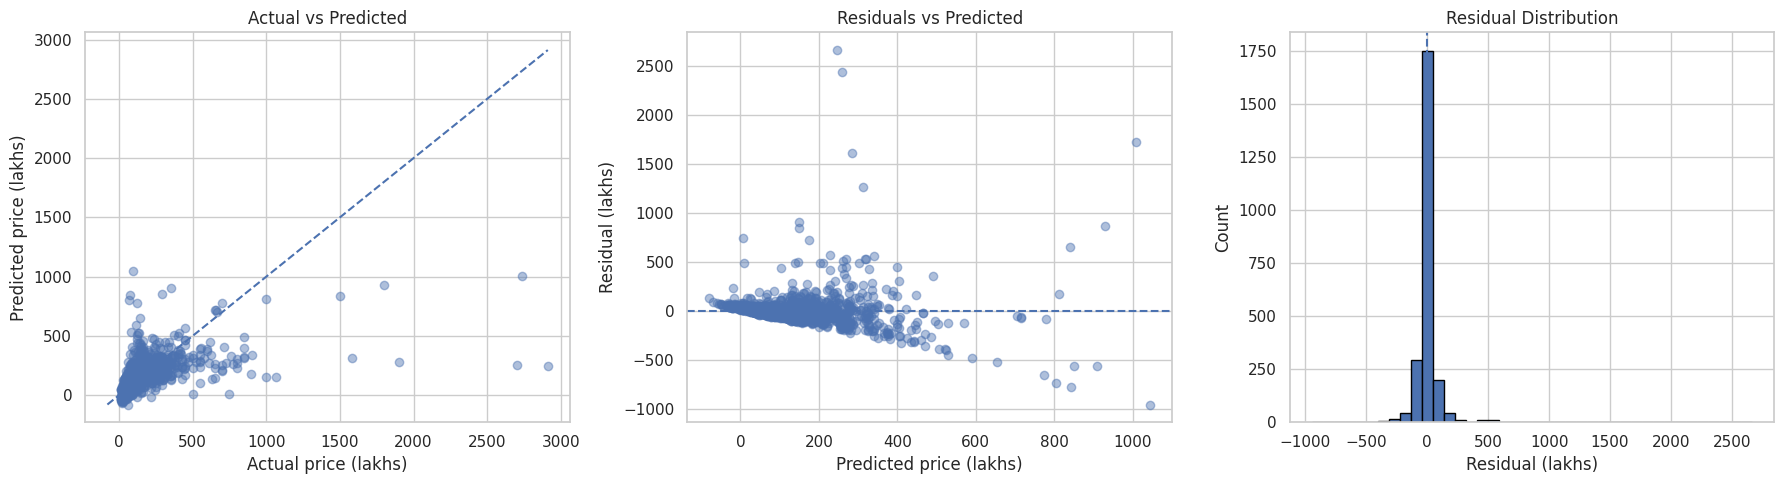

Mean test residual:   1.188 lakhs
Median test residual: -4.107 lakhs


In [18]:
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, y_test_pred, alpha=0.45)
lims = [
    min(y_test.min(), y_test_pred.min()),
    max(y_test.max(), y_test_pred.max()),
]
axes[0].plot(lims, lims, linestyle="--")
axes[0].set_title("Actual vs Predicted")
axes[0].set_xlabel("Actual price (lakhs)")
axes[0].set_ylabel("Predicted price (lakhs)")

axes[1].scatter(y_test_pred, residuals, alpha=0.45)
axes[1].axhline(0, linestyle="--")
axes[1].set_title("Residuals vs Predicted")
axes[1].set_xlabel("Predicted price (lakhs)")
axes[1].set_ylabel("Residual (lakhs)")

axes[2].hist(residuals, bins=40, edgecolor="black")
axes[2].axvline(0, linestyle="--")
axes[2].set_title("Residual Distribution")
axes[2].set_xlabel("Residual (lakhs)")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

print(f"Mean test residual:   {residuals.mean():.3f} lakhs")
print(f"Median test residual: {residuals.median():.3f} lakhs")

## 11. Inspect model coefficients

Linear regression coefficients describe the expected change in the model's predicted price associated with a one-unit change in a numeric feature **after preprocessing**, while categorical coefficients represent differences relative to the dropped reference category.

Because numeric predictors were standardised, their coefficient magnitudes can be compared more meaningfully with each other than they could on their original scales. Categorical coefficients should still be interpreted as category effects rather than as a universal ranking of feature importance.

In [19]:
feature_names = linear_model.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = linear_model.named_steps[
    "regressor"
].coef_

coef_df = (
    pd.DataFrame({
        "feature": feature_names,
        "coefficient_lakhs": coefficients,
        "absolute_coefficient": np.abs(coefficients),
    })
    .sort_values("absolute_coefficient", ascending=False)
)

display(coef_df.head(25))

,feature,coefficient_lakhs,absolute_coefficient
360,categorical__location_Yemlur,866.072,866.072
124,categorical__location_Dollars Colony,610.958,610.958
110,categorical__location_Defence Colony,602.372,602.372
291,categorical__location_Ramakrishnappa Layout,572.589,572.589
298,categorical__location_Sadashiva Nagar,482.290,482.290
106,categorical__location_Cunningham Road,464.678,464.678
123,categorical__location_Dodsworth Layout,357.935,357.935
98,categorical__location_Chikka Tirupathi,-250.037,250.037
210,categorical__location_Kattigenahalli,-247.859,247.859
350,categorical__location_Vishveshwarya Layout,-246.815,246.815


## 12. Example prediction

The following function demonstrates how the trained pipeline can be used for a new property.

The prediction is expressed in lakhs because that is the unit of the target variable.

In [20]:
def predict_price(
    location,
    total_sqft,
    bhk,
    bath,
    balcony=np.nan,
    area_type="Super built-up  Area",
    ready_to_move=1,
):
    new_property = pd.DataFrame([{
        "location": location,
        "total_sqft": total_sqft,
        "bhk": bhk,
        "bath": bath,
        "balcony": balcony,
        "area_type": area_type,
        "ready_to_move": ready_to_move,
    }])

    return float(linear_model.predict(new_property)[0])


examples = pd.DataFrame([
    {
        "location": "Whitefield",
        "total_sqft": 1200,
        "bhk": 2,
        "bath": 2,
        "balcony": 1,
        "area_type": "Super built-up  Area",
        "ready_to_move": 1,
    },
    {
        "location": "Rajaji Nagar",
        "total_sqft": 1800,
        "bhk": 3,
        "bath": 3,
        "balcony": 2,
        "area_type": "Super built-up  Area",
        "ready_to_move": 1,
    },
    {
        "location": "Electronic City",
        "total_sqft": 2500,
        "bhk": 4,
        "bath": 4,
        "balcony": 2,
        "area_type": "Built-up  Area",
        "ready_to_move": 1,
    },
])

examples["predicted_price_lakhs"] = linear_model.predict(
    examples[feature_columns]
)

examples["predicted_price_inr"] = (
    examples["predicted_price_lakhs"] * 100000
)

display(examples)

,location,total_sqft,bhk,bath,balcony,area_type,ready_to_move,predicted_price_lakhs,predicted_price_inr
0,Whitefield,1200,2,2,1,Super built-up Area,1,71.074,"7,107,390.265"
1,Rajaji Nagar,1800,3,3,2,Super built-up Area,1,325.128,"32,512,769.193"
2,Electronic City,2500,4,4,2,Built-up Area,1,166.749,"16,674,936.295"


## 13. Final findings

The final conclusions should be based on the executed results above rather than on assumptions made before modelling.

### What the analysis demonstrates

- The raw dataset required substantial cleaning before modelling.
- `total_sqft`, bedroom count, bathroom count, location and area type provide useful predictive information.
- Location is a high-cardinality variable, so rare locations were grouped using a training-data-only rule.
- `price_per_sqft` was useful for exploration but excluded from modelling to prevent target leakage.
- The required linear regression model performs substantially better than a simple mean-price baseline, although a linear model does not explain all variation in house prices.
- Residual diagnostics should be considered when interpreting the model's limitations.

### Limitations

1. The dataset is historical and may not represent current Bengaluru market prices.
2. The dataset does not contain all factors that can influence property prices.
3. Location grouping sacrifices some fine-grained geographic information.
4. `availability` was simplified to a ready-to-move indicator.
5. Linear regression imposes a relatively simple functional form and may miss nonlinear relationships.
6. The model should therefore be treated as a capstone predictive model, not as an authoritative property valuation system.

## 14. Reproducibility checklist

Before sharing this project:

- [x] Dataset path is defined clearly.
- [x] Random state is fixed.
- [x] Cleaning rules are explicit.
- [x] Target leakage is controlled.
- [x] Location grouping is learned from training data only.
- [x] Preprocessing is inside a scikit-learn pipeline.
- [x] Cross-validation is performed on training data only.
- [x] Test data is reserved for final evaluation.
- [x] A simple baseline is reported.
- [x] RMSE and MAE are reported in lakhs.
- [x] Residual diagnostics are included.
- [x] Limitations are documented.

**Next step:** move the final notebook into a clean GitHub repository together with a README, requirements file and appropriate project structure.